## Importing Libraries
Importing the necessary libraries at the beginning for data manipulation, visualization, and modeling

In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score

In [57]:
#Reading in the COMPAS dataset from ProPublica GitHub source
url = "https://raw.githubusercontent.com/propublica/compas-analysis/master/compas-scores-two-years.csv"
raw_data = pd.read_csv(url)

#Checking number of rows in raw dataset to ensure it matched the R code from lecture
len(raw_data)

7214

In [58]:
#Previewing the first 10 rows to understand the inital raw structure of the data
raw_data.head(10)

,id,name,first,last,compas_screening_date,sex,dob,age,age_cat,race,...,v_decile_score,v_score_text,v_screening_date,in_custody,out_custody,priors_count.1,start,end,event,two_year_recid
0,1,miguel hernandez,miguel,hernandez,2013-08-14,Male,1947-04-18,69,Greater than 45,Other,...,1,Low,2013-08-14,2014-07-07,2014-07-14,0,0,327,0,0
1,3,kevon dixon,kevon,dixon,2013-01-27,Male,1982-01-22,34,25 - 45,African-American,...,1,Low,2013-01-27,2013-01-26,2013-02-05,0,9,159,1,1
2,4,ed philo,ed,philo,2013-04-14,Male,1991-05-14,24,Less than 25,African-American,...,3,Low,2013-04-14,2013-06-16,2013-06-16,4,0,63,0,1
3,5,marcu brown,marcu,brown,2013-01-13,Male,1993-01-21,23,Less than 25,African-American,...,6,Medium,2013-01-13,NaN,NaN,1,0,1174,0,0
4,6,bouthy pierrelouis,bouthy,pierrelouis,2013-03-26,Male,1973-01-22,43,25 - 45,Other,...,1,Low,2013-03-26,NaN,NaN,2,0,1102,0,0
5,7,marsha miles,marsha,miles,2013-11-30,Male,1971-08-22,44,25 - 45,Other,...,1,Low,2013-11-30,2013-11-30,2013-12-01,0,1,853,0,0
6,8,edward riddle,edward,riddle,2014-02-19,Male,1974-07-23,41,25 - 45,Caucasian,...,2,Low,2014-02-19,2014-03-31,2014-04-18,14,5,40,1,1
7,9,steven stewart,steven,stewart,2013-08-30,Male,1973-02-25,43,25 - 45,Other,...,3,Low,2013-08-30,2014-05-22,2014-06-03,3,0,265,0,0
8,10,elizabeth thieme,elizabeth,thieme,2014-03-16,Female,1976-06-03,39,25 - 45,Caucasian,...,1,Low,2014-03-16,2014-03-15,2014-03-18,0,2,747,0,0
9,13,bo bradac,bo,bradac,2013-11-04,Male,1994-06-10,21,Less than 25,Caucasian,...,5,Medium,2013-11-04,2015-01-06,2015-01-07,1,0,428,1,1


However not all of the rows are useable for the first round of analysis.

There are a number of reasons remove rows because of missing data:
* If the charge date of a defendants Compas scored crime was not within 30 days from when the person was arrested, we assume that because of data quality reasons, that we do not have the right offense.
* We coded the recidivist flag -- `is_recid` -- to be -1 if we could not find a compas case at all.
* In a similar vein, ordinary traffic offenses -- those with a `c_charge_degree` of 'O' -- will not result in Jail time are removed (only two of them).
* We filtered the underlying data from Broward county to include only those rows representing people who had either recidivated in two years, or had at least two years outside of a correctional facility.

In [59]:
#Defining the numeric variables and the datetime ones for type conversions
numeric_vars = ["age", "priors_count", "days_b_screening_arrest", "decile_score"]
datetime_vars = ["c_jail_in", "c_jail_out"]

#Selecting only the variables used in the workflow
df = raw_data[["age", "c_charge_degree", "race", "age_cat",
               "score_text", "sex", "priors_count",
               "days_b_screening_arrest", "decile_score", "is_recid",
               "two_year_recid", "c_jail_in", "c_jail_out"]]

#-----------Filtering
df = df[
    (df["days_b_screening_arrest"].between(-30,30)) &
    (df["is_recid"] != -1) &
    (df["c_charge_degree"] != "0") &
    (df["score_text"] != "N/A")
]

#------------Type conversions
#Converting the datetime variables into the datetime format
df[datetime_vars] = df[datetime_vars].apply(pd.to_datetime, errors="coerce") #coerce is so the notebook doesnt crash

#Converting the nonnumeric, nondatetime columns into category type
cat_cols = df.columns.difference(numeric_vars + datetime_vars)
df[cat_cols] = df[cat_cols].astype("category")

#Creating factor style categorical variables for modeling
df["crime_factor"] = df["c_charge_degree"].astype("category")

df["age_factor"] = df["age_cat"].astype("category")
df["age_factor"] = df["age_factor"].cat.reorder_categories(
    ["25 - 45", "Less than 25", "Greater than 45"]
)

df["race_factor"] = df["race"].astype("category")
df["race_factor"] = df["race_factor"].cat.reorder_categories(
    ["Caucasian", "African-American", "Hispanic", "Other", "Asian", "Native American"]
)

df["gender_factor"] = df["sex"].astype("category")
df["gender_factor"] = df["gender_factor"].cat.reorder_categories(
    ["Male", "Female"]
)

#Collapsing the score_text variable into a binary categorical outcome.
df["score_factor"] = df["score_text"].apply(
    lambda x: "LowScore" if x == "Low" else "HighScore"
).astype("category")

#Ensuring to see it matches the R code
len(df)


6172

In [60]:
#Preview the cleaned dataset
df.head()

,age,c_charge_degree,race,age_cat,score_text,sex,priors_count,days_b_screening_arrest,decile_score,is_recid,two_year_recid,c_jail_in,c_jail_out,crime_factor,age_factor,race_factor,gender_factor,score_factor
0,69,F,Other,Greater than 45,Low,Male,0,-1.0,1,0,0,2013-08-13 06:03:42,2013-08-14 05:41:20,F,Greater than 45,Other,Male,LowScore
1,34,F,African-American,25 - 45,Low,Male,0,-1.0,3,1,1,2013-01-26 03:45:27,2013-02-05 05:36:53,F,25 - 45,African-American,Male,LowScore
2,24,F,African-American,Less than 25,Low,Male,4,-1.0,4,1,1,2013-04-13 04:58:34,2013-04-14 07:02:04,F,Less than 25,African-American,Male,LowScore
5,44,M,Other,25 - 45,Low,Male,0,0.0,1,0,0,2013-11-30 04:50:18,2013-12-01 12:28:56,M,25 - 45,Other,Male,LowScore
6,41,F,Caucasian,25 - 45,Medium,Male,14,-1.0,6,1,1,2014-02-18 05:08:24,2014-02-24 12:18:30,F,25 - 45,Caucasian,Male,HighScore


In [61]:
#Inspecting the data further
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6172 entries, 0 to 7213
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   age                      6172 non-null   int64         
 1   c_charge_degree          6172 non-null   category      
 2   race                     6172 non-null   category      
 3   age_cat                  6172 non-null   category      
 4   score_text               6172 non-null   category      
 5   sex                      6172 non-null   category      
 6   priors_count             6172 non-null   int64         
 7   days_b_screening_arrest  6172 non-null   float64       
 8   decile_score             6172 non-null   int64         
 9   is_recid                 6172 non-null   category      
 10  two_year_recid           6172 non-null   category      
 11  c_jail_in                6172 non-null   datetime64[ns]
 12  c_jail_out               6172 non-null 

Higher COMPAS scores are slightly correlated with a longer length of stay

In [62]:
#Creating the length of stay using the difference between jail out and jail in
df["length_of_stay"] = (df["c_jail_out"] - df["c_jail_in"]).dt.days
float(df["length_of_stay"].corr(df["decile_score"]))

0.20747808478031807

After filtering we have the following demographic breakdown

In [63]:
#Counting observations by age category
df["age_cat"].value_counts()

,count
age_cat,
25 - 45,3532
Less than 25,1347
Greater than 45,1293


In [64]:
#Counting observations by race category
df["race"].value_counts()

,count
race,
African-American,3175
Caucasian,2103
Hispanic,509
Other,343
Asian,31
Native American,11


In [65]:
print(f"Black defendants: {3175 / 6172 * 100:.2f}%")
print(f"White defendants: {2103 / 6172 * 100:.2f}%")
print(f"Hispanic defendants: {509 / 6172 * 100:.2f}%")
print(f"Asian defendants: {31 / 6172 * 100:.2f}%")
print(f"Native American defendants: {11 / 6172 * 100:.2f}%")

Black defendants: 51.44%
White defendants: 34.07%
Hispanic defendants: 8.25%
Asian defendants: 0.50%
Native American defendants: 0.18%


In [66]:
#Count COMPAS score categories
df["score_text"].value_counts()

,count
score_text,
Low,3421
Medium,1607
High,1144


In [67]:
#Crosstab of Sex by Race
pd.crosstab(df["sex"], df["race"])

race,African-American,Asian,Caucasian,Hispanic,Native American,Other
sex,,,,,,
Female,549,2,482,82,2,58
Male,2626,29,1621,427,9,285


In [68]:
df["sex"].value_counts()

,count
sex,
Male,4997
Female,1175


In [69]:
print("Men: %.2f%%" %   (4997 / 6172 * 100))
print("Women: %.2f%%" % (1175 / 6172 * 100))

Men: 80.96%
Women: 19.04%


In [70]:
#Counting number of defendants who recidivated within two years
len(df[df["two_year_recid"] == 1])

2809

In [71]:
#Calculating the two-year recidivism rate
len(df[df["two_year_recid"] == 1]) / len(df) * 100

45.51198963058976

Judges are often presented with two sets of scores from the Compas system -- one that classifies people into High, Medium and Low risk, and a corresponding decile score. There is a clear downward trend in the decile scores as those scores increase for white defendants.

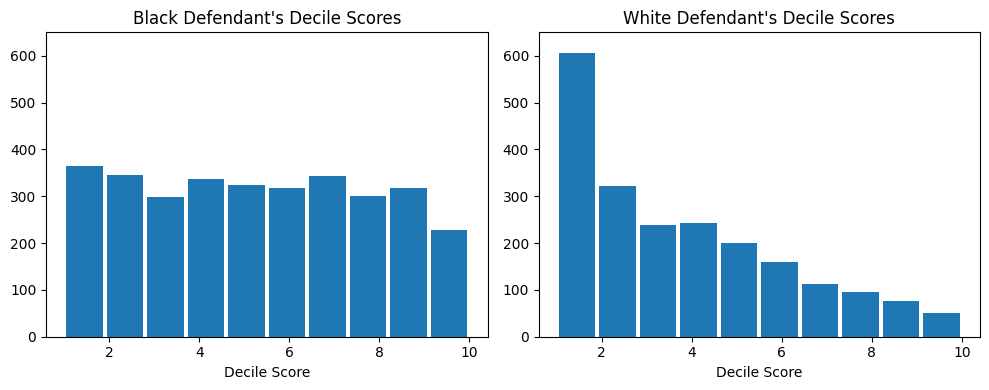

In [72]:
#Filtering data
black_df = df[df["race"] == "African-American"]
white_df = df[df["race"] == "Caucasian"]

#Creates a side by side histogram plot
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

#Black defendants plot
axes[0].hist(black_df["decile_score"], bins=10, rwidth = 0.9)
axes[0].set_title("Black Defendant's Decile Scores")
axes[0].set_xlabel("Decile Score")
axes[0].set_ylim(0, 650)

#White defendants plot
axes[1].hist(white_df["decile_score"], bins=10, rwidth = 0.9)
axes[1].set_title("White Defendant's Decile Scores")
axes[1].set_xlabel("Decile Score")
axes[1].set_ylim(0, 650)

plt.tight_layout()
plt.show()

###Interpretation
The White defendants distribution is more rightly-skewed, with more observations in the lower deciles. On the other hand, the Black defendants are more evenly distributed across the decile score range.

In [73]:
#Cross-tabs decile score by race
pd.crosstab(df["decile_score"], df["race"])

race,African-American,Asian,Caucasian,Hispanic,Native American,Other
decile_score,,,,,,
1,365,15,605,159,0,142
2,346,4,321,89,2,60
3,298,5,238,73,1,32
4,337,0,243,47,0,39
5,323,1,200,39,0,19
6,318,2,160,27,2,20
7,343,1,113,28,2,9
8,301,2,96,14,0,7
9,317,0,77,17,2,7


## Racial Bias in Compas

After filtering out bad rows, our first question is whether there is a significant difference in Compas scores between races. To do so we need to change some variables into factors, and run a logistic regression, comparing low scores to high scores.

In [74]:
#fitting the log model
model_glm = smf.glm(
    "score_factor ~ gender_factor + age_factor + race_factor + priors_count + crime_factor + two_year_recid",
    data=df,
    family=sm.families.Binomial()
).fit()

print(model_glm.summary())

                                   Generalized Linear Model Regression Results                                   
Dep. Variable:     ['score_factor[HighScore]', 'score_factor[LowScore]']   No. Observations:                 6172
Model:                                                               GLM   Df Residuals:                     6160
Model Family:                                                   Binomial   Df Model:                           11
Link Function:                                                     Logit   Scale:                          1.0000
Method:                                                             IRLS   Log-Likelihood:                -3084.2
Date:                                                   Sat, 28 Mar 2026   Deviance:                       6168.4
Time:                                                           20:30:55   Pearson chi2:                 6.07e+03
No. Iterations:                                                        6   Pseudo R-squ.

###Interpretation:
The logistic regression model predicts whether someone received a high COMPAS score based on features like gender, age, race, prior offenses, type of crime, and if they have reoffended in the past two years. The results illustrate that race is still an important predictor even after controlling for all other factors. Specifically, African-American defendants have a positive coefficient and it is statistically significant, meaning they are more likely to receive a high risk score compared to Caucasian defendants (who are the reference group). Other variables behave how they are expected. People with more priors and those who have recently reoffended also have positive statistically significant scores, giving them a higher chance of receiving a higher score. Younger individuals are more likely to receive scores, compared to older individuals. Gender has a slight impact as well, with females slightly more likely to have high scores than males (reference).

Black defendants are 45% more likely than white defendants to receive a higher score correcting for the seriousness of their crime, previous arrests, and future criminal behavior

In [75]:
#Baseline or "control" predicted probability based on intercept
control = np.exp(-1.52554) / (1 + np.exp(-1.52554))

float(np.exp(0.47721) / (1 - control + (control * np.exp(0.47721))))

1.4528408658138932

Women are 19.4% more likely than men to get a higher score

In [76]:
float(np.exp(0.22127) / (1 - control + (control * np.exp(0.22127))))

1.1947978508506671

In [77]:
float(np.exp(1.30839) / (1 - control + (control * np.exp(1.30839))))

2.4961202077189455

In [78]:
#predicted probabilities
df["pred_prob"] = model_glm.predict(df)

#predicted class
df["pred_class"] = (df["pred_prob"] >= 0.5).astype(int)

#map to labels
df["pred_class"] = df["pred_class"].map({0: "No Recid", 1: "Recid"})

In [79]:
print("\nOverall Confusion Matrix\n")

#confusion matrix using predicted laels vs actual recidivism
overall_cm = pd.crosstab(
    df["pred_class"],
    df["two_year_recid"],
    rownames=["Predicted"],
    colnames=["Actual"]
)

print(overall_cm)

#confusion matrix counts
TP = overall_cm.loc["Recid", 1]
TN = overall_cm.loc["No Recid", 0]
FP = overall_cm.loc["Recid", 0]
FN = overall_cm.loc["No Recid", 1]

n = overall_cm.values.sum()

print(f"\nAccuracy  : {(TP + TN) / n:.3f}")
print(f"Precision : {TP / (TP + FP):.3f}")
print(f"Recall    : {TP / (TP + FN):.3f}")
print(f"FPR       : {FP / (FP + TN):.3f}")
print(f"FNR       : {FN / (FN + TP):.3f}")


Overall Confusion Matrix

Actual        0     1
Predicted            
No Recid   2653   945
Recid       710  1864

Accuracy  : 0.732
Precision : 0.724
Recall    : 0.664
FPR       : 0.211
FNR       : 0.336


###Interpretation
The confusion matrix shows how well the model predicts those who reoffend (recidivism). Overall, the model has a 73.2% accuracy so classifying it for most cases. A precision of 72.4% indicates when a model predicts someone will reoffend, its correct about 72.4% of the time. The recall of 66.4% means the model identifies about 66.4% of reoffenders. There is a False Positive rate of 21.1% meaning that some individuals who did not reoffend are incorrectly predicted as high risk of reoffense. The false negative rate is 33.6% meaning that those individuals who reoffended are missed by the models prediction. Overall the model performs reasonably well but still makes some meaningful errors.

In [80]:
print("\nConfusion Matrix by Race\n")

# Actual and predicted binary columns for calculation
df["actual"] = df["two_year_recid"].astype(int)
df["pred"] = (df["pred_class"] == "Recid").astype(int)

# Confusion matrix components within each race group
race_metrics = (
    df.groupby("race")
      .apply(lambda x: pd.Series({
          "n":  len(x),
          "TP": ((x["pred"] == 1) & (x["actual"] == 1)).sum(),
          "TN": ((x["pred"] == 0) & (x["actual"] == 0)).sum(),
          "FP": ((x["pred"] == 1) & (x["actual"] == 0)).sum(),
          "FN": ((x["pred"] == 0) & (x["actual"] == 1)).sum()
      }))
      .reset_index()
)

# Performance metrics by race
race_metrics["Accuracy"]  = round((race_metrics["TP"] + race_metrics["TN"]) / race_metrics["n"], 3)
race_metrics["Precision"] = round(race_metrics["TP"] / (race_metrics["TP"] + race_metrics["FP"]), 3)
race_metrics["Recall"]    = round(race_metrics["TP"] / (race_metrics["TP"] + race_metrics["FN"]), 3)
race_metrics["FPR"]       = round(race_metrics["FP"] / (race_metrics["FP"] + race_metrics["TN"]), 3)
race_metrics["FNR"]       = round(race_metrics["FN"] / (race_metrics["FN"] + race_metrics["TP"]), 3)

# Sort by group size (same as before, just cleaner)
race_metrics = race_metrics.sort_values("n", ascending=False)

print(race_metrics)


Confusion Matrix by Race

               race     n    TP    TN   FP   FN  Accuracy  Precision  Recall  \
0  African-American  3175  1373   959  555  288     0.734      0.712   0.827   
2         Caucasian  2103   381  1148  133  441     0.727      0.741   0.464   
3          Hispanic   509    81   306   14  108     0.760      0.853   0.429   
5             Other   343    22   216    3  102     0.694      0.880   0.177   
1             Asian    31     2    22    1    6     0.774      0.667   0.250   
4   Native American    11     5     2    4    0     0.636      0.556   1.000   

     FPR    FNR  
0  0.367  0.173  
2  0.104  0.536  
3  0.044  0.571  
5  0.014  0.823  
1  0.043  0.750  
4  0.667  0.000  


/tmp/ipykernel_3102/3081169644.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("race")
/tmp/ipykernel_3102/3081169644.py:10: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: pd.Series({


####Note:
Unsure why the chart splits and gives the future warning, I tried researching how to fix but nothing I could understand

###Interpretation
The confusion matrix by race shows the models preformance is not consistent across groups. For African-American defendants, the model has high recall meaning it correctly identifies individuals who actually reoffended, but it also has a high false positive rate, meaning more people who do not reoffend are incorrectly labeled as high risk. For caucasian defendants, the recall has a low recall of 46.4%. Although it has a low False positive rate, it has a high false negative rate of 53.6% meaning it misses more individuals who actually reoffend. Other race groups show mixed results, mainly due to the lower number of sample size, making them overall less reliable.

In [81]:
print("\nFPR and FNR Disparity by Race\n")

#Keeping only race and error-rate columns
disparity = race_metrics[["race", "n", "FPR", "FNR"]].copy()

#Caucasian defendants are the baseline comparison group
base_FPR = disparity.loc[disparity["race"] == "Caucasian", "FPR"].values[0]
base_FNR = disparity.loc[disparity["race"] == "Caucasian", "FNR"].values[0]

#Calculating disparities relative to the caucasian baseline calculared
disparity["delta_FPR"] = (disparity["FPR"] - base_FPR).round(3)
disparity["delta_FNR"] = (disparity["FNR"] - base_FNR).round(3)

print(disparity)


FPR and FNR Disparity by Race

               race     n    FPR    FNR  delta_FPR  delta_FNR
0  African-American  3175  0.367  0.173      0.263     -0.363
2         Caucasian  2103  0.104  0.536      0.000      0.000
3          Hispanic   509  0.044  0.571     -0.060      0.035
5             Other   343  0.014  0.823     -0.090      0.287
1             Asian    31  0.043  0.750     -0.061      0.214
4   Native American    11  0.667  0.000      0.563     -0.536


### Interpretation:
The disparity table for FPR and FNR compares the error rates across the racial groups using Caucasian as baseline. African-American defendants have a higher FPR +0.263 meaning they are more likely than Caucasian defendants to be incorrectly labeled as high risk, even though they don't reoffend. They do have a lower false negative rate (-0.363) meaning the model is less likely to miss actual reoffenders in the group. Other racial groups like Hispanic, Other, and Asian also have lower FPR but higher FNR, meaning they are less likely to be incorrectly labeled, but more likely to have actual reoffenders. Native Americans have a high delta FPR of 0.563 but thats because of the small sample rize making the results not as reliable.